# 07 · Train CFFM-Net

The method in image mode: two YOLO26-n backbones, a reliability-weighted sum at stride 4, CMFM at strides 8 to 32 and a stride-4 detection head. Trained on LLVIP and M3FD with the baselines' settings.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot`, raw LLVIP and M3FD (or the output of 02) |
| **Expected runtime** | about 3 to 3.5 hours on 2 x T4 |
| **Produces** | checkpoints in `runs/<run>/`, full-set metrics in `runs/eval/<run>/metrics.json` |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


## The runs

Straight from `configs/pilot.yaml`. Batch is the total over both GPUs.

In [2]:
specs = pipeline.runs_for(plan, "07")

import pandas as pd
cols = ["name", "model", "data", "epochs", "imgsz", "batch"]
pd.DataFrame(specs)[cols]

,name,model,data,epochs,imgsz,batch
0,llvip_cffm,configs/models/cffm-net-n.yaml,llvip/data_paired.yaml,30,640,16
1,m3fd_cffm,configs/models/cffm-net-n.yaml,m3fd/data_paired.yaml,30,640,16


## Train and evaluate

In [3]:
results = [pipeline.train_from_spec(s, env) for s in specs]

[llvip_cffm] already trained, reusing C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs\llvip_cffm\weights\best.pt


Ultralytics 8.4.171  Python-3.12.10 torch-2.14.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)


cffm-net-n summary: 319 layers, 5,916,970 parameters, 0 gradients, 16.9 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 875.7200.0 MB/s, size: 125.2 KB)


val: Scanning C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed\llvip\labels\visible\val.cache... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463  0.0s

...

 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.850


 Average Recall     (AR) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.918


 Average Recall     (AR) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.630


Results saved to C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs\eval\m3fd_cffm


[m3fd_cffm] AP50-95 0.4790  AP50 0.7726  AP_s 0.4275


## Learning curves

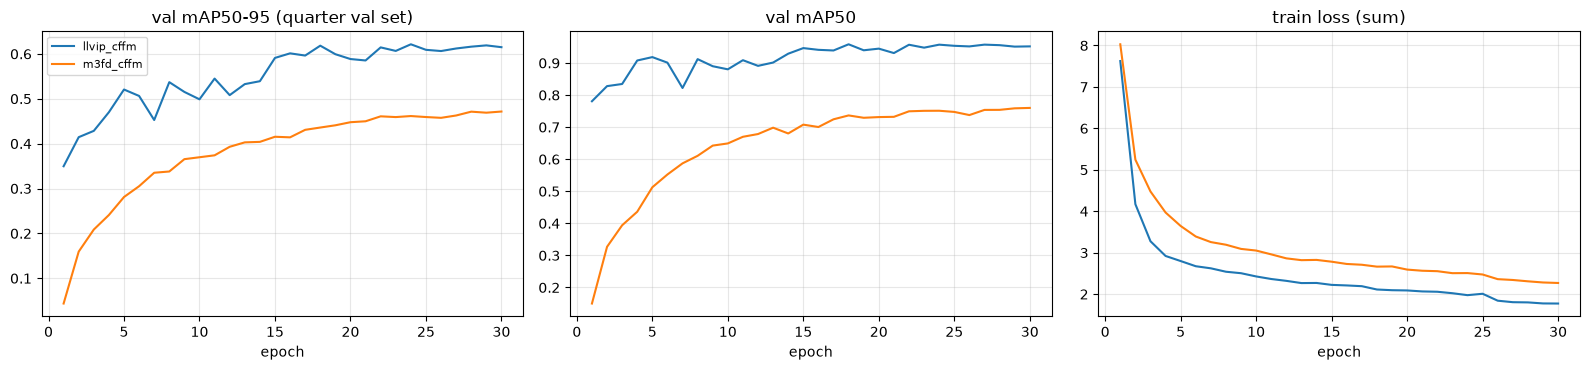

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for s in specs:
    f = env.runs / s["name"] / "results.csv"
    if not f.exists():
        continue
    df = pd.read_csv(f)
    df.columns = [c.strip() for c in df.columns]
    axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label=s["name"])
    axes[1].plot(df["epoch"], df["metrics/mAP50(B)"], label=s["name"])
    loss_cols = [c for c in df.columns if c.startswith("train/") and c.endswith("loss")]
    axes[2].plot(df["epoch"], df[loss_cols].sum(axis=1), label=s["name"])
for a, t in zip(axes, ["val mAP50-95 (quarter val set)", "val mAP50", "train loss (sum)"]):
    a.set_title(t); a.set_xlabel("epoch"); a.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Results on the full validation set

In [5]:
import pandas as pd
keys = ["mAP50-95(B)", "mAP50(B)", "mAP_small(B)", "AP_vt(B)", "AP_t(B)", "AP_s(B)", "AP_m(B)", "AP_l(B)"]
rows = [{"run": r["run"], **{k.replace("(B)", ""): r["metrics"].get(k) for k in keys}} for r in results]
pd.DataFrame(rows).set_index("run").round(4)

,mAP50-95,mAP50,mAP_small,AP_vt,AP_t,AP_s,AP_m,AP_l
run,,,,,,,,
llvip_cffm,0.6289,0.9576,0.0885,NaN,NaN,0.0885,0.6267,0.6493
m3fd_cffm,0.4790,0.7726,0.2974,0.0595,0.1899,0.4275,0.5899,0.8023


## What it sees

The model's detections on night scenes, with the thermal view and the fusion trust map (blue: visible weighted, orange: thermal weighted), and a log of every subject.

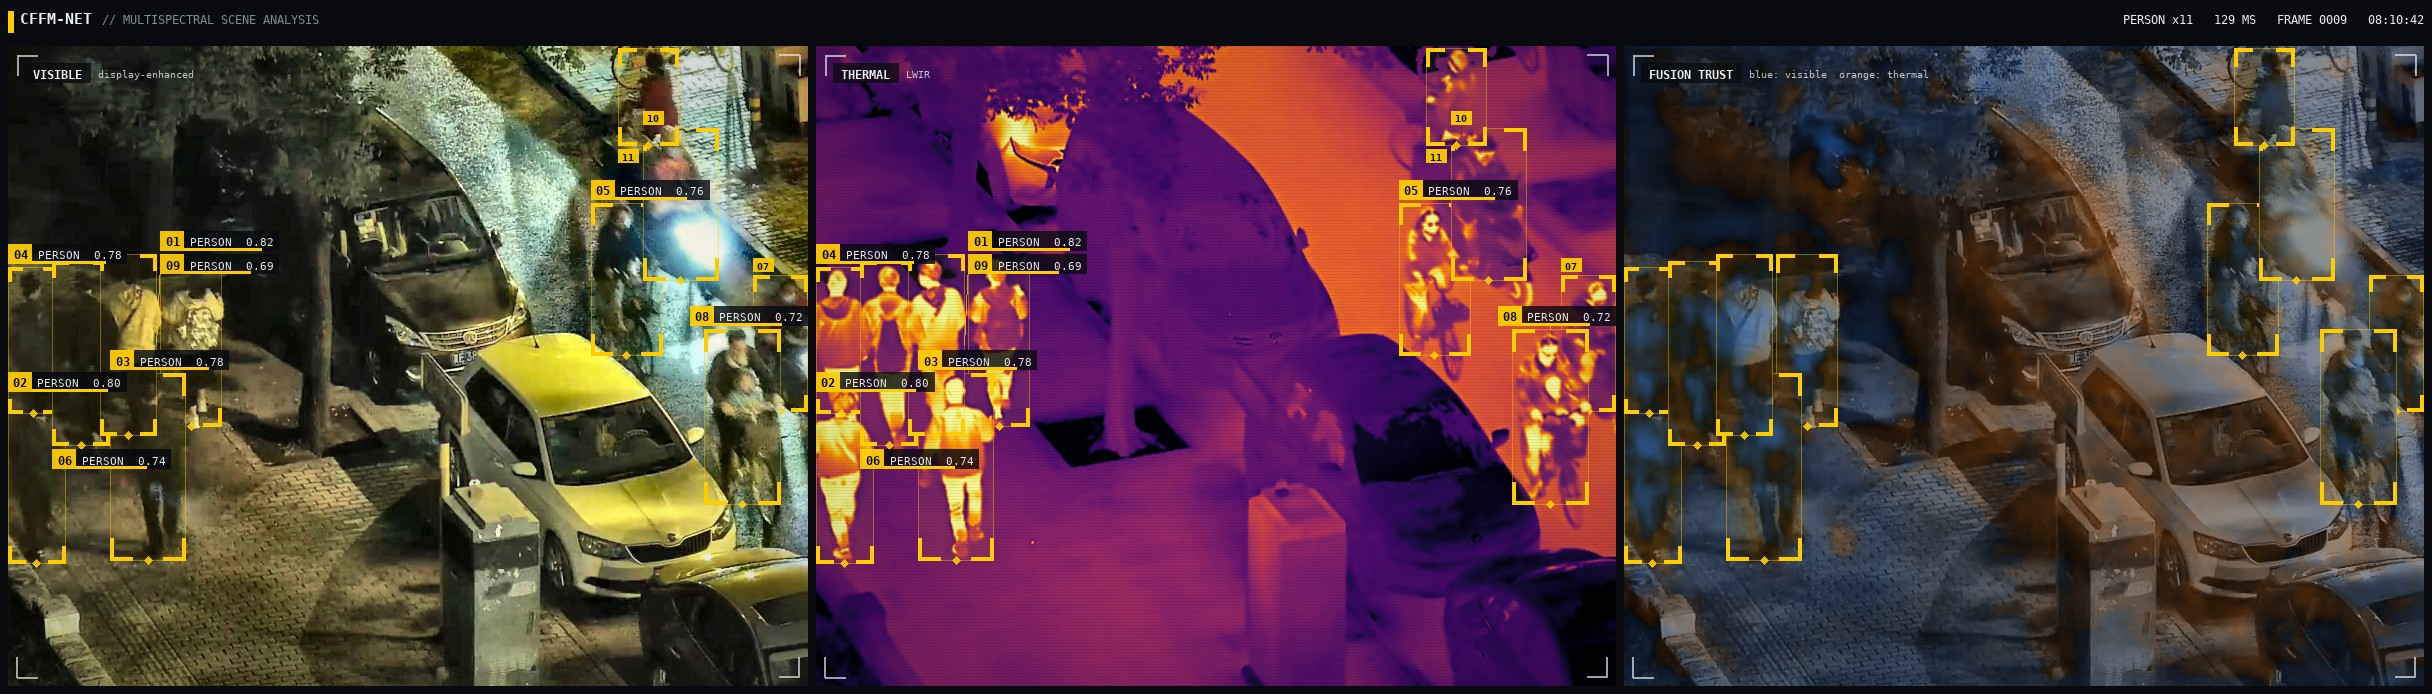

,class,conf,box px,thermal trust
subject,,,,
01,PERSON,0.821,98x275,0.48
02,PERSON,0.804,91x269,0.46
03,PERSON,0.782,119x298,0.47
04,PERSON,0.777,78x233,0.46
05,PERSON,0.760,113x243,0.48
06,PERSON,0.742,90x294,0.48
07,PERSON,0.720,86x217,0.50
08,PERSON,0.716,121x280,0.47
09,PERSON,0.694,90x288,0.43


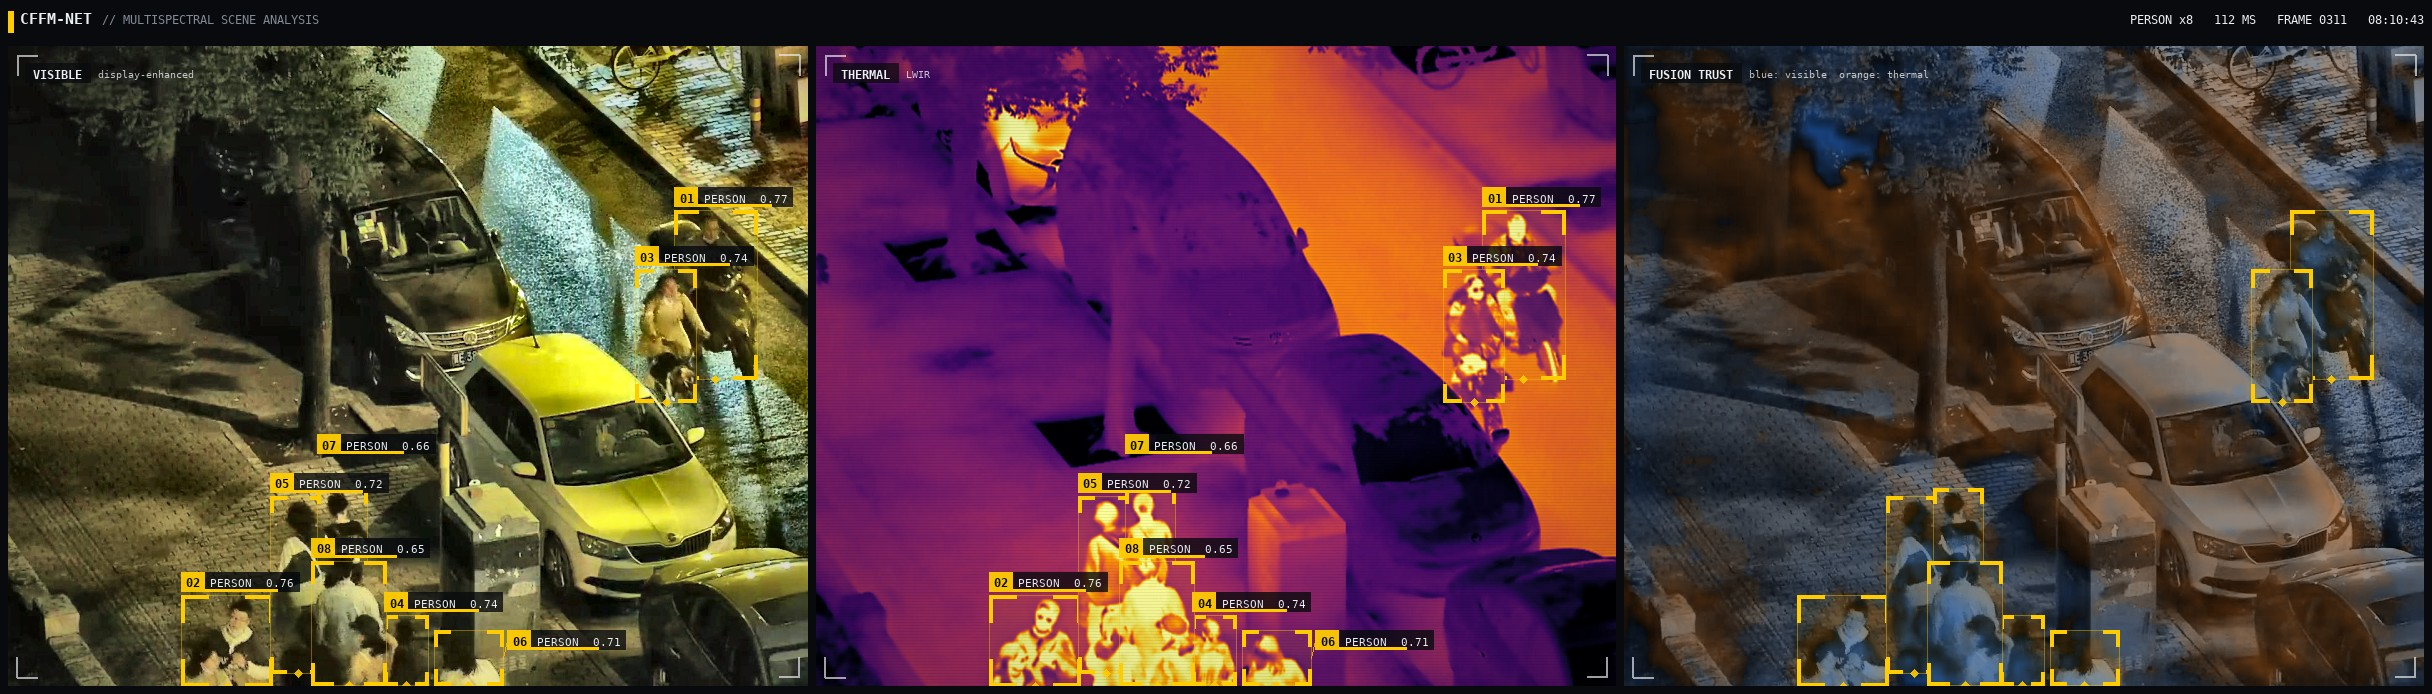

,class,conf,box px,thermal trust
subject,,,,
01,PERSON,0.772,132x270,0.47
02,PERSON,0.764,146x145,0.46
03,PERSON,0.744,98x211,0.45
04,PERSON,0.738,69x111,0.43
05,PERSON,0.725,89x283,0.45
06,PERSON,0.712,111x87,0.48
07,PERSON,0.664,80x151,0.47
08,PERSON,0.649,120x199,0.37


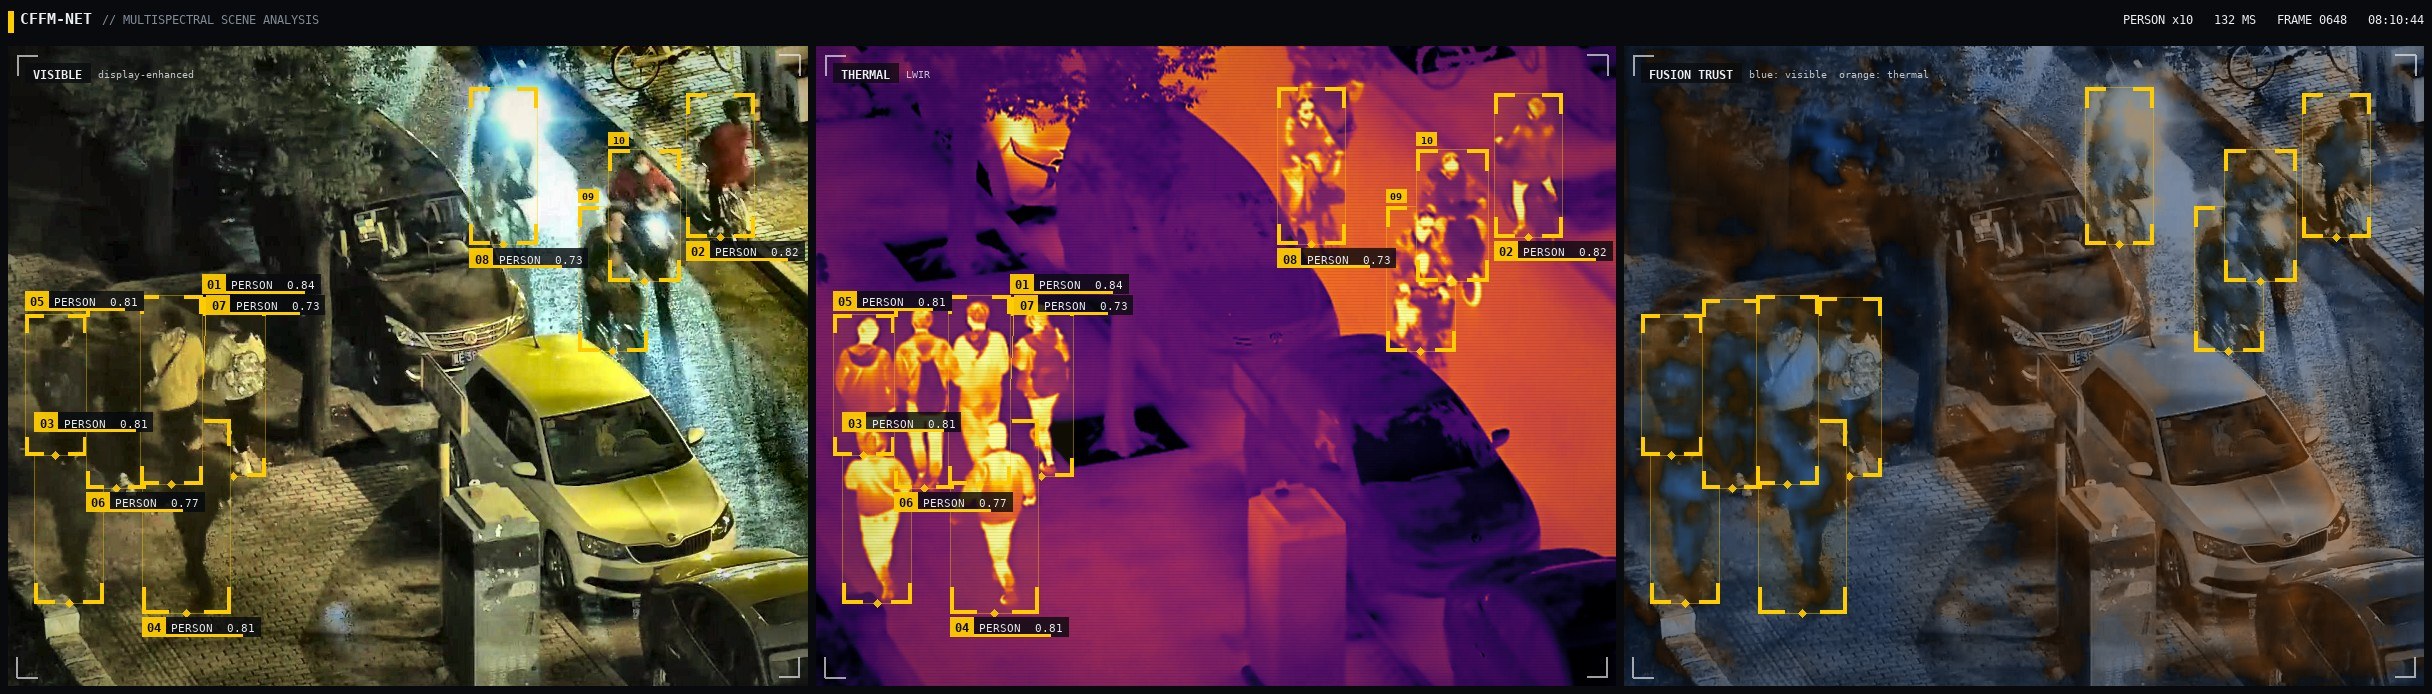

,class,conf,box px,thermal trust
subject,,,,
01,PERSON,0.836,100x287,0.50
02,PERSON,0.815,108x230,0.51
03,PERSON,0.811,109x268,0.47
04,PERSON,0.810,140x309,0.46
05,PERSON,0.808,98x225,0.50
06,PERSON,0.769,95x301,0.49
07,PERSON,0.727,99x302,0.43
08,PERSON,0.726,109x250,0.49
09,PERSON,0.642,110x231,0.45


In [6]:
from IPython.display import display
from cffm import hud, showcase as sc
from cffm.train import _load
model = _load(env.runs / "llvip_cffm" / "weights" / "best.pt").to("cuda:0")
for stem in sc.crowded(env.data / "llvip", k=3):
    a = hud.analyze(model, *sc.pair_paths(env, "llvip", stem), frame=int(stem) % 10000)
    sc.show(a.board)
    display(sc.subject_log(a.det, a.names, a.share))

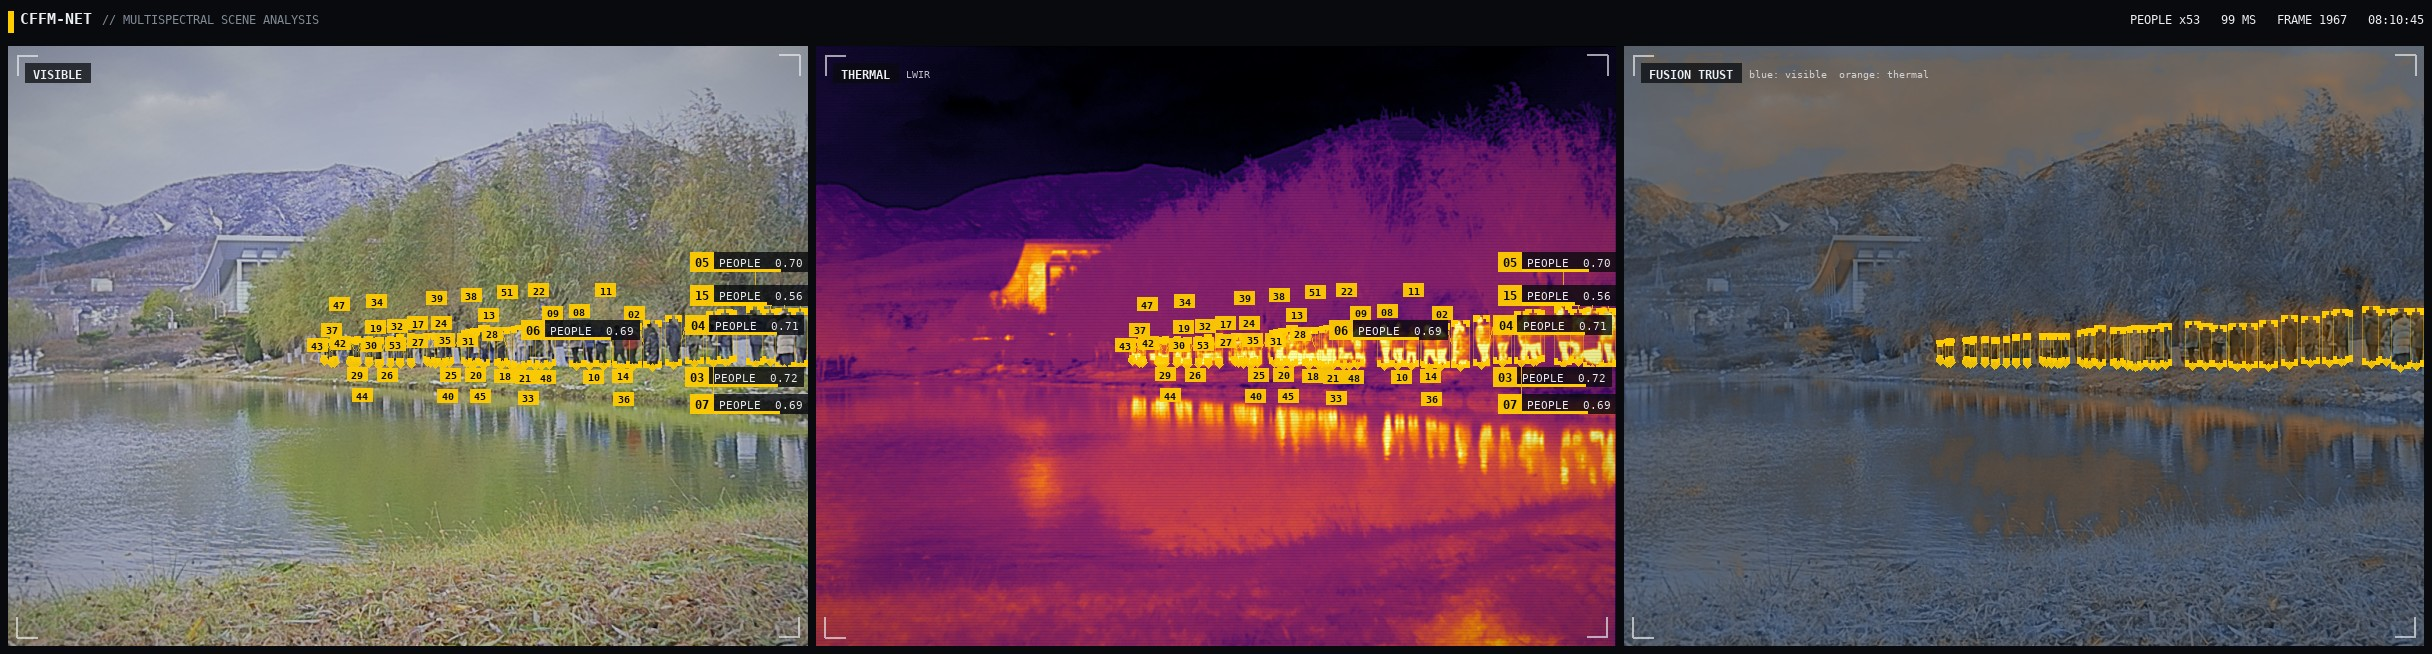

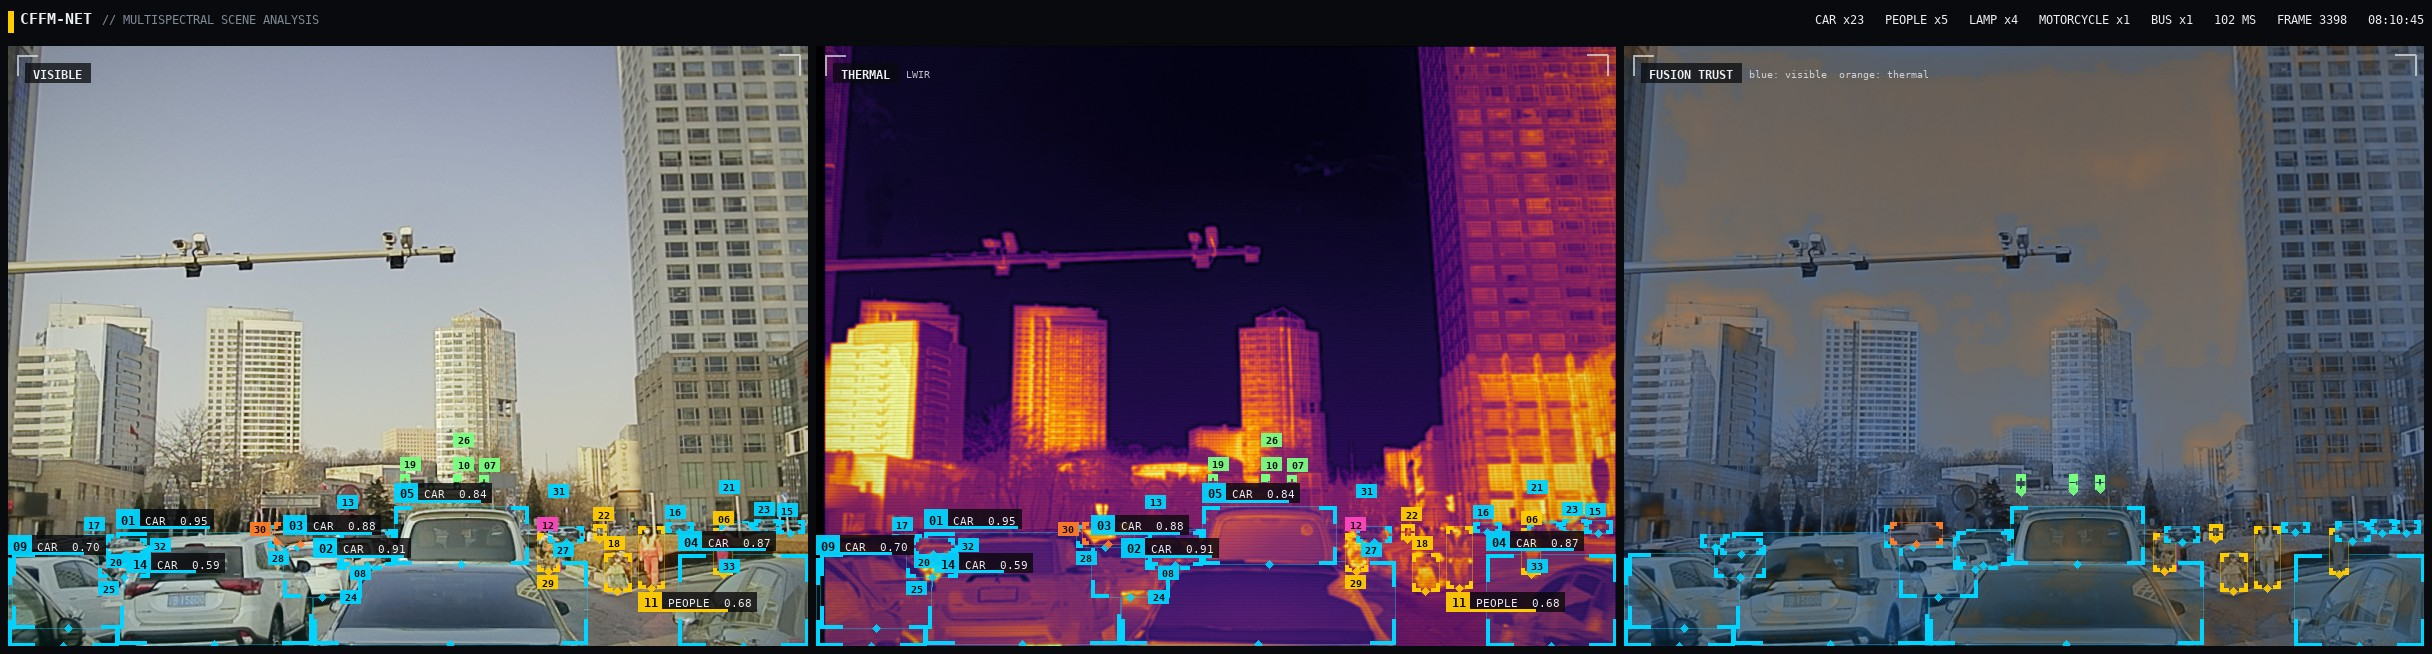

In [7]:
model = _load(env.runs / "m3fd_cffm" / "weights" / "best.pt").to("cuda:0")
for stem in sc.crowded(env.data / "m3fd", k=2):
    sc.show(hud.analyze(model, *sc.pair_paths(env, "m3fd", stem), frame=int(stem) % 10000).board)

In [8]:
if env.platform == "kaggle":
    shutil.rmtree(env.data, ignore_errors=True)

### Keep the results

On Kaggle, click **Save Version → Save & Run All (Commit)** so `runs/` becomes an output that notebooks **09**
and **15** can attach (*Add Input → Your Work → this notebook*). Without a saved version the checkpoints vanish.